In [30]:
from utils import *
from keras.applications.resnet50 import preprocess_input as resnet_preprocess

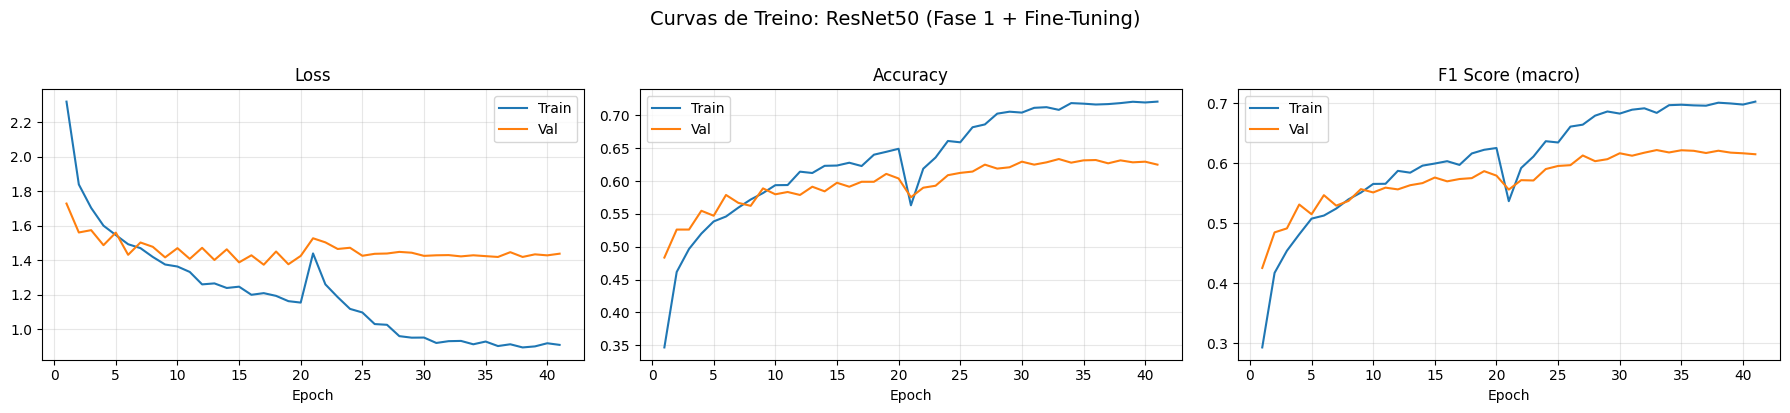

Best epoch (lowest val_loss): 17
  Val Loss: 1.3738
  Val Acc:  0.5989
  Val F1:   0.5734


In [31]:
# 1. Carregar o histórico guardado (usando o mesmo caminho)
resnet = "models_results/resnet50/resnet50_history.json"
resnet_history = load_history(resnet)

# 2. Plottar as curvas de treino
plot_learning_curves(resnet_history, title="Curvas de Treino: ResNet50 (Fase 1 + Fine-Tuning)")


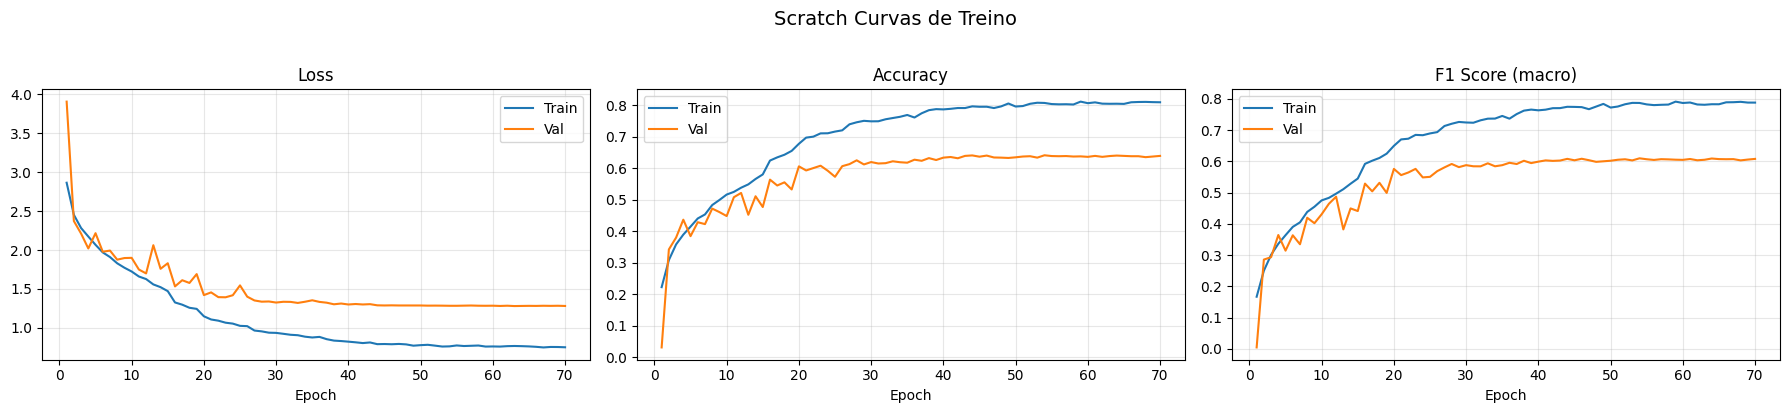

Best epoch (lowest val_loss): 63
  Val Loss: 1.2802
  Val Acc:  0.6386
  Val F1:   0.6049


In [32]:
# 1. Carregar o histórico guardado (usando o mesmo caminho)
scratch = "models_results/scratch/scratch_history.json"
scratch_history = load_history(scratch)

# 2. Plottar as curvas de treino
plot_learning_curves(scratch_history, title="Scratch Curvas de Treino")


In [33]:
model_scratch = keras.models.load_model("models_results/scratch/scratch_best.keras")
model_resnet = keras.models.load_model("models_results/resnet50/resnet50_best.keras")

Found 9326 files belonging to 23 classes.
Found 1992 files belonging to 23 classes.
Found 2022 files belonging to 23 classes.
Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']

  CNN Scratch - Test Evaluation
  Test Loss:     1.2592
  Test Accuracy: 0.6489
  Test F1 Macro: 0.6232

Classification Report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.70      0.75      0.72        87
      Boris_Kustodiev       0.51      0.38      0.44        68
     Camille_Pissarro       0.59      0.61      0.60        94
        Childe_Hassam       0.57      0.44      0.50        5

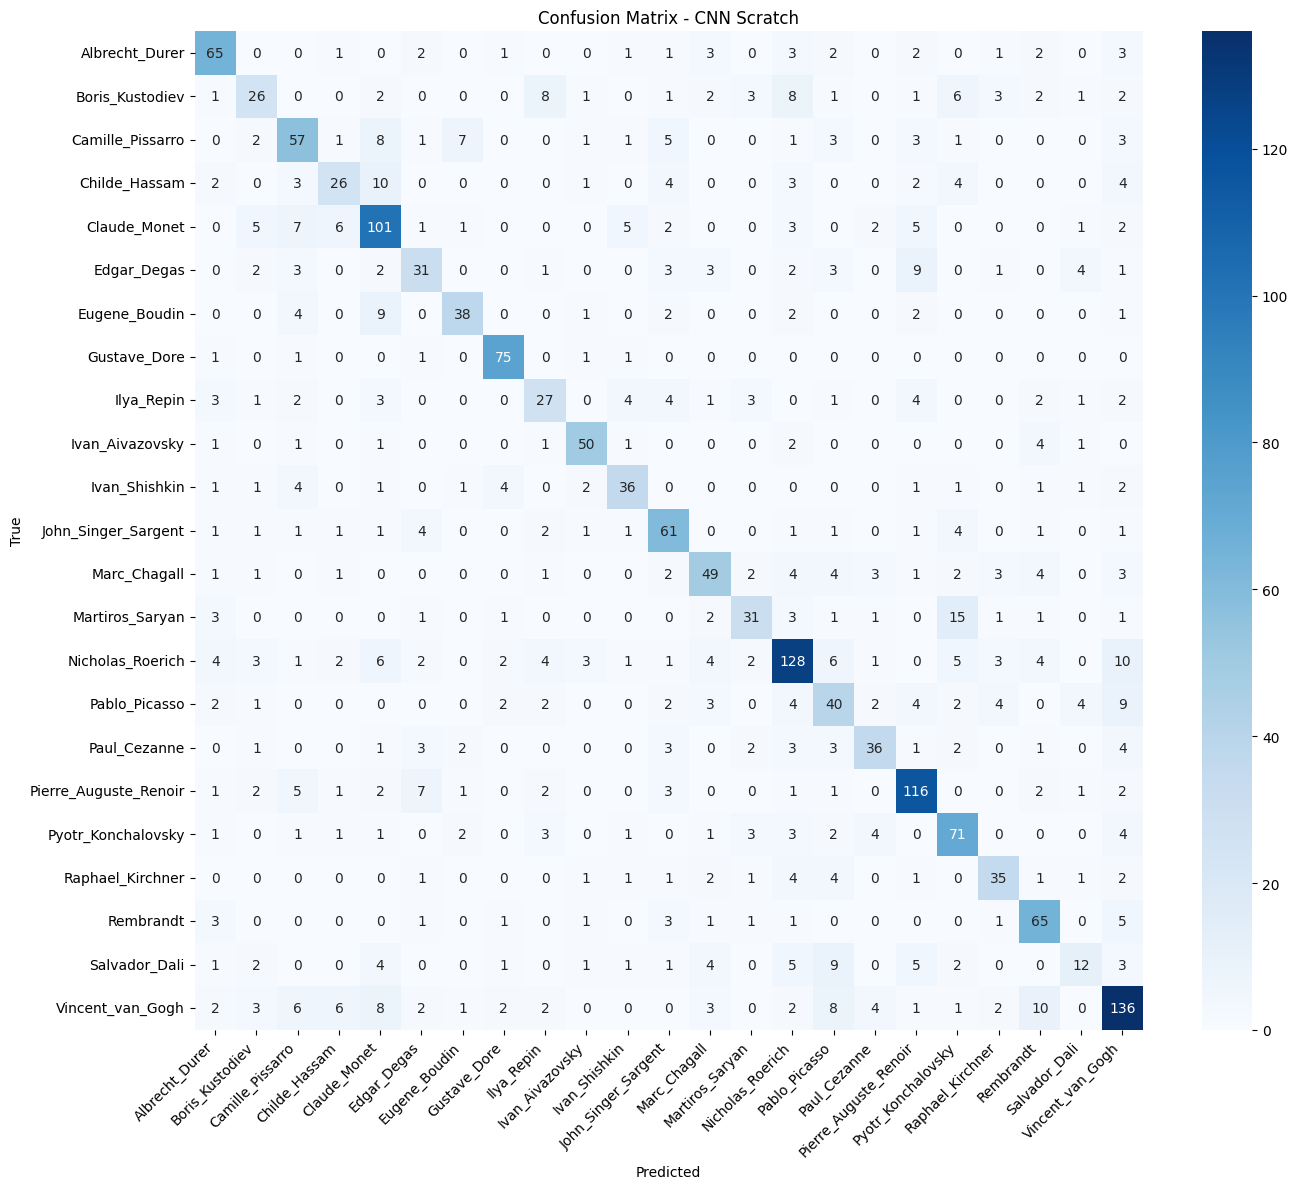

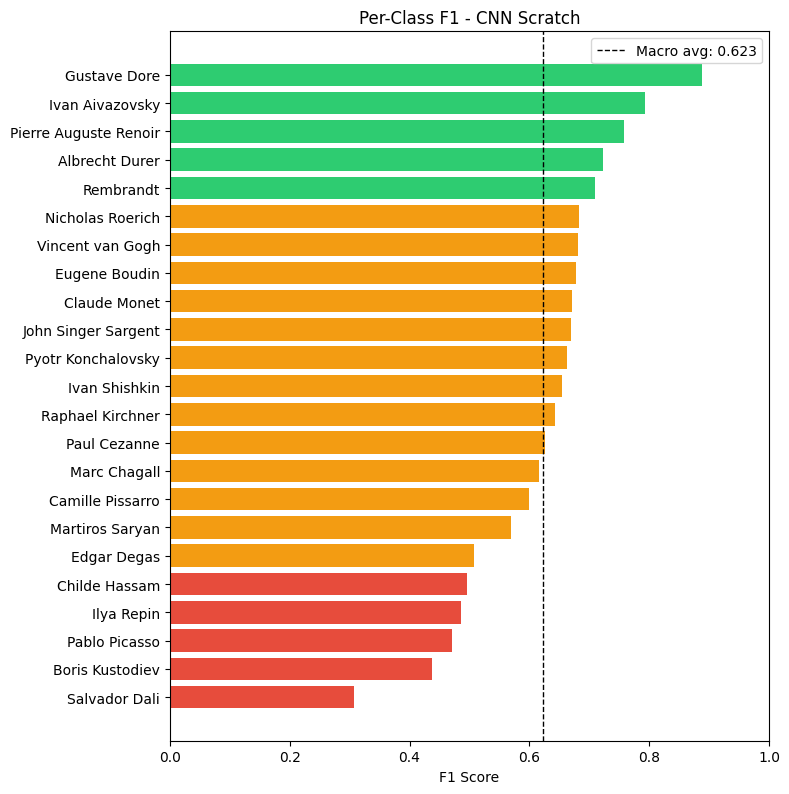


  ResNet50 Fine-tuned - Test Evaluation
  Test Loss:     1.4123
  Test Accuracy: 0.6004
  Test F1 Macro: 0.5740

Classification Report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.72      0.72      0.72        87
      Boris_Kustodiev       0.40      0.21      0.27        68
     Camille_Pissarro       0.58      0.48      0.52        94
        Childe_Hassam       0.44      0.41      0.42        59
         Claude_Monet       0.64      0.59      0.61       141
          Edgar_Degas       0.71      0.52      0.60        65
        Eugene_Boudin       0.70      0.73      0.72        59
         Gustave_Dore       0.86      0.86      0.86        80
           Ilya_Repin       0.43      0.43      0.43        58
      Ivan_Aivazovsky       0.80      0.85      0.83        62
        Ivan_Shishkin       0.74      0.46      0.57        56
  John_Singer_Sargent       0.70      0.52      0.60        83
         Marc_Chagall       0.71      0.42 

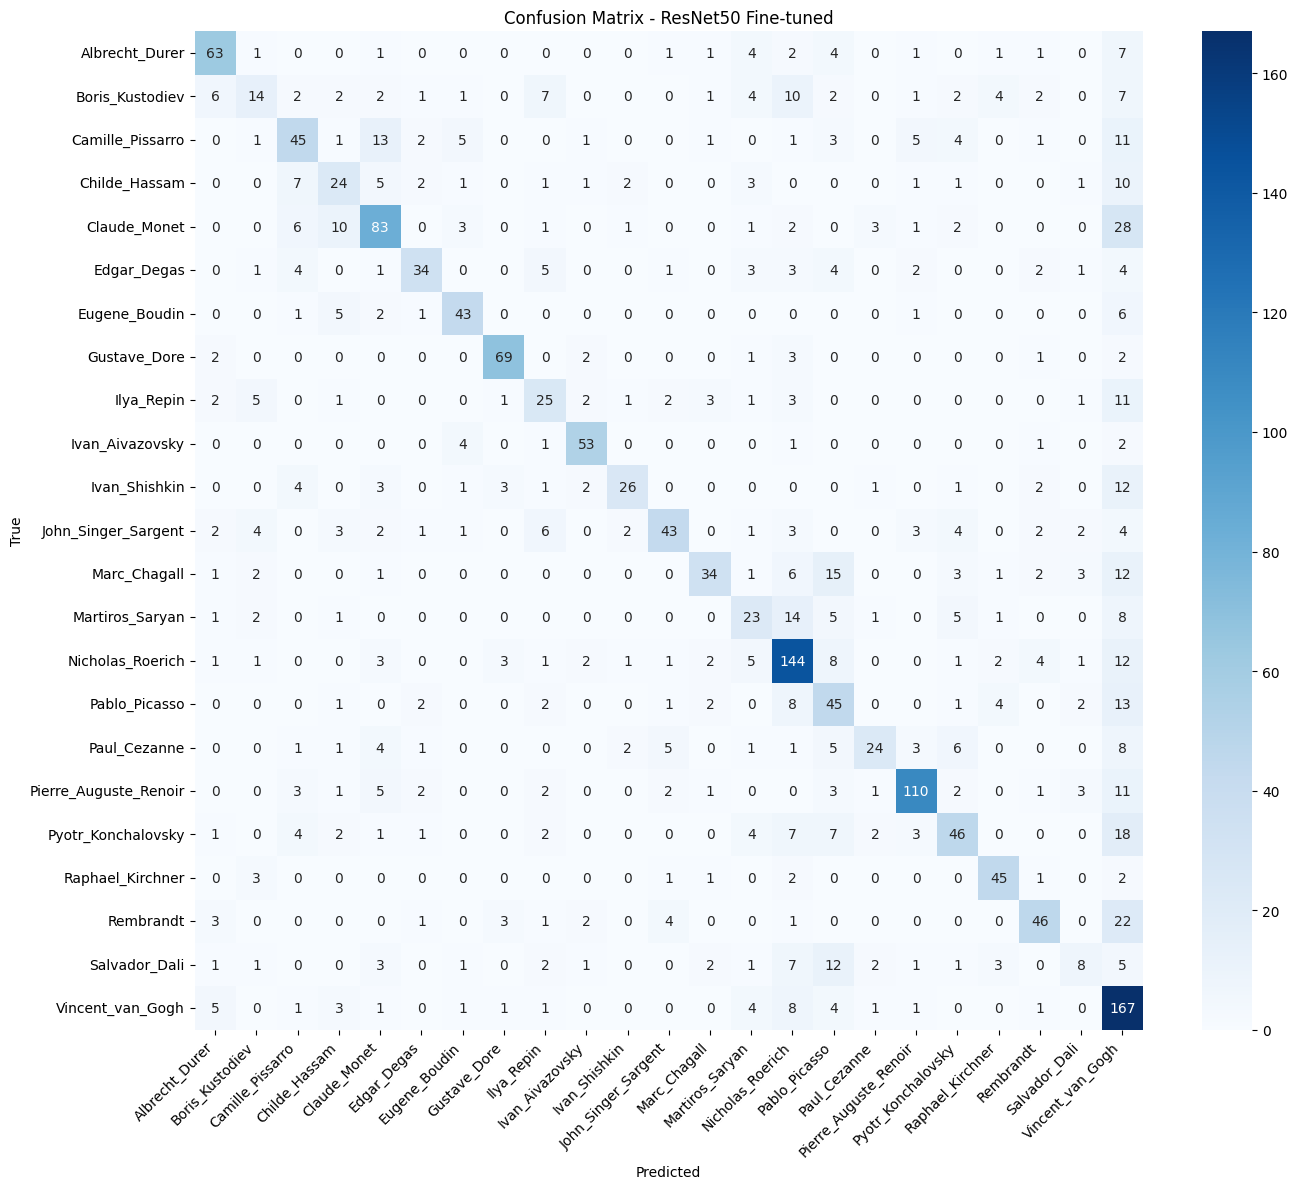

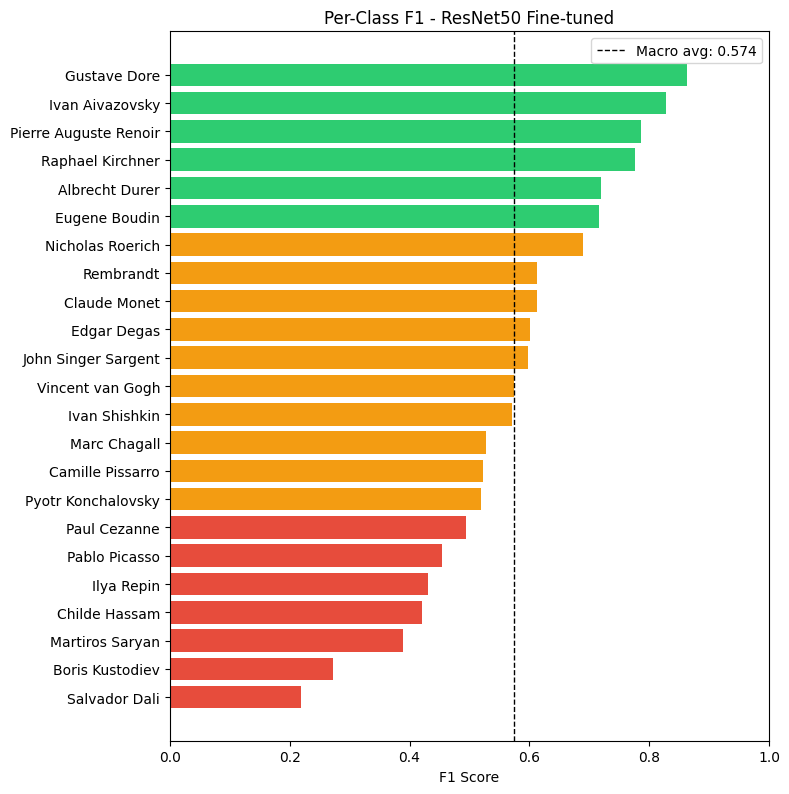


  Model Comparison
Model                            Accuracy   F1 (macro)       Loss
-----------------------------------------------------------------
CNN Scratch                        0.6489       0.6232     1.2592
ResNet50 Fine-tuned                0.6004       0.5740     1.4123
-----------------------------------------------------------------


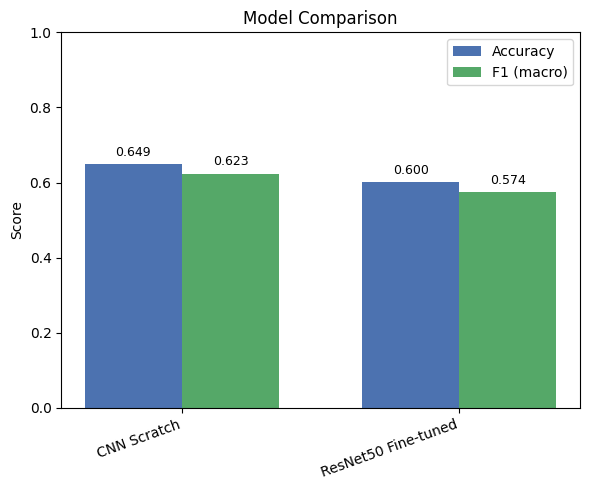

In [38]:
train_dir = "data/train"
val_dir   = "data/val"
test_dir  = "data/test"

# Ambos os modelos foram treinados com 128x128
# e têm preprocessing DENTRO do modelo
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

_, _, test_ds, class_names = load_datasets(
    train_dir, val_dir, test_dir,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

# Carregar modelos
model_scratch = keras.models.load_model("models_results/scratch/scratch_best.keras")
model_resnet  = keras.models.load_model("models_results/resnet50/resnet50_best.keras")

# Avaliar — mesmo test_ds para os dois
metrics_cnn    = evaluate_model(model_scratch, test_ds, class_names, model_name="CNN Scratch")
metrics_resnet = evaluate_model(model_resnet,  test_ds, class_names, model_name="ResNet50 Fine-tuned")

compare_models([metrics_cnn, metrics_resnet])